# LIBERO-90 Task 0 Dataloader Smoke Test

This notebook creates a dataloader for `antoniomari/libero_90` filtered to task `0`, then inspects:

- one training batch (`obs`, `actions`)
- one transformed dataset sample (`dataset[0]`)
- image-like tensors rendered for visual sanity checks

In [1]:
from pathlib import Path
import os
import sys
from typing import Any

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/cluster/home/anmari/meta_vlas')
for p in [PROJECT_ROOT, PROJECT_ROOT / 'src', PROJECT_ROOT / 'meta_libero']:
    p = str(p)
    if p not in sys.path:
        sys.path.insert(0, p)

os.environ.setdefault('HF_HOME', str(Path.home() / '.cache' / 'huggingface'))
os.environ.setdefault('HF_LEROBOT_HOME', str(Path(os.environ['HF_HOME']) / 'lerobot'))

import openpi.training.config as _config
import openpi.training.data_loader as _data_loader
from meta_libero.src.dataset import override_create_torch_dataset

print('Setup done.')
print('HF_LEROBOT_HOME =', os.environ['HF_LEROBOT_HOME'])

2026-03-07 15:00:18.851005: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-07 15:00:18.851168: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-07 15:00:18.965861: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-07 15:00:21.383100: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /cluster/home/anmari/meta_vlas/.venv/lib/python3.11/si

Setup done.
HF_LEROBOT_HOME = /cluster/home/anmari/.cache/huggingface/lerobot


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
repo_id = 'antoniomari/libero_90'
task_id = 0

train_config = _config.get_config('pi05_libero')

with override_create_torch_dataset(repo_id=repo_id, task_id=task_id):
    dataloader = _data_loader.create_data_loader(
        train_config,
        sharding=None,
        shuffle=False,
    )

# Keep a handle to the underlying dataset object used by the dataloader.
dataset = dataloader._data_loader._data_loader.dataset

print('Repo ID:', repo_id)
print('Task ID:', task_id)
print('Dataloader type:', type(dataloader))
print('Dataset type:', type(dataset))
print('Dataset length:', len(dataset))

Resolving data files:   0%|          | 0/3917 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/109 [00:00<?, ?it/s]

Filtering dataset for task_index=55 and episode_index=None...
Building task index cache for repo 'antoniomari/libero_90'...
Task index cache built with 73 tasks
Filtered dataset (cached): 7339 / 567494 samples
Repo ID: antoniomari/libero_90
Task ID: 0
Dataloader type: <class 'openpi.training.data_loader.DataLoaderImpl'>
Dataset type: <class 'openpi.training.data_loader.TransformedDataset'>
Dataset length: 7339


/cluster/home/anmari/meta_vlas/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [3]:
obs, actions = next(iter(dataloader))

print('Batch observation type:', type(obs))
print('Batch actions type:', type(actions))

# Observation is a dataclass; convert to dict for shape inspection.
obs_dict = obs.to_dict() if hasattr(obs, 'to_dict') else obs

def shape_tree(x: Any):
    if isinstance(x, dict):
        return {k: shape_tree(v) for k, v in x.items()}
    if hasattr(x, 'shape'):
        return tuple(x.shape)
    return type(x).__name__

print('\nObservation tree (shapes):')
print(shape_tree(obs_dict))
print('\nActions shape:', tuple(actions.shape) if hasattr(actions, 'shape') else type(actions))

2026-03-07 15:01:10.332430: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-07 15:01:10.332980: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-07 15:01:10.334063: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-07 15:01:11.416834: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /cluster/home/anmari/meta_vlas/.venv/lib/python3.11/si

Batch observation type: <class 'openpi.models.model.Observation'>
Batch actions type: <class 'jaxlib.xla_extension.ArrayImpl'>

Observation tree (shapes):
{'state': (256, 32), 'tokenized_prompt': (256, 200), 'tokenized_prompt_mask': (256, 200), 'token_ar_mask': 'NoneType', 'token_loss_mask': 'NoneType', 'image': {'base_0_rgb': (256, 224, 224, 3), 'left_wrist_0_rgb': (256, 224, 224, 3), 'right_wrist_0_rgb': (256, 224, 224, 3)}, 'image_mask': {'base_0_rgb': (256,), 'left_wrist_0_rgb': (256,), 'right_wrist_0_rgb': (256,)}}

Actions shape: (256, 10, 32)


In [4]:
sample = dataset[0]
print('Sample type:', type(sample))

# Print top-level keys and shape-like info.
if isinstance(sample, dict):
    print('Top-level keys:', list(sample.keys()))
    for k, v in sample.items():
        if hasattr(v, 'shape'):
            print(f'  {k}: shape={tuple(v.shape)}, dtype={getattr(v, "dtype", type(v))}')
        else:
            print(f'  {k}: type={type(v)}')
else:
    print('Sample is not dict; repr:')
    print(sample)

Sample type: <class 'dict'>
Top-level keys: ['state', 'image', 'image_mask', 'actions', 'task_index', 'tokenized_prompt', 'tokenized_prompt_mask']
  state: shape=(32,), dtype=float64
  image: type=<class 'dict'>
  image_mask: type=<class 'dict'>
  actions: shape=(10, 32), dtype=float64
  task_index: shape=(), dtype=torch.int64
  tokenized_prompt: shape=(200,), dtype=int64
  tokenized_prompt_mask: shape=(200,), dtype=bool


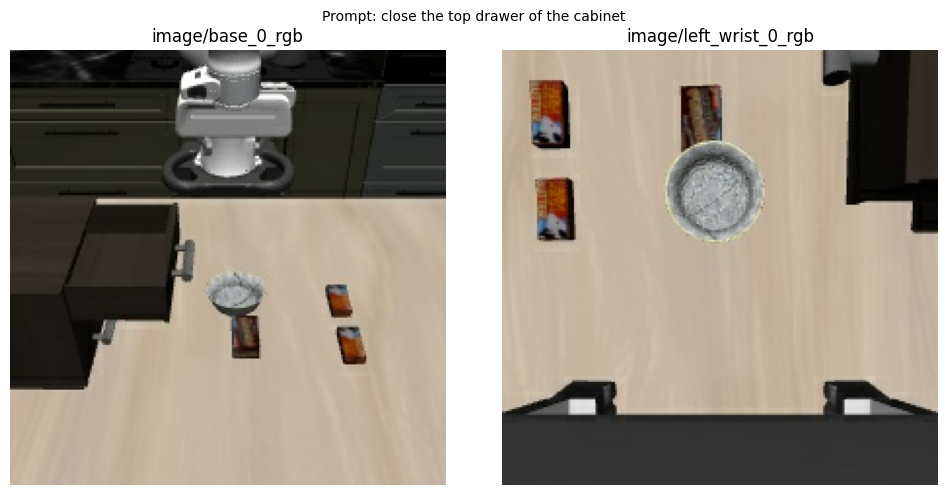

In [33]:
# Visualize image-like arrays from sample (supports nested dicts, HWC or CHW).
# Ignore right_wrist view (masked out / all zeros) and show prompt in title.

def to_hwc_uint8(arr):
    arr = np.asarray(arr)
    if arr.ndim == 4:  # take first item if accidentally batched
        arr = arr[0]
    if arr.ndim == 3 and arr.shape[0] == 3:  # CHW -> HWC
        arr = np.transpose(arr, (1, 2, 0))
    if arr.ndim != 3 or arr.shape[-1] != 3:
        return None
    if np.issubdtype(arr.dtype, np.floating):
        lo, hi = float(arr.min()), float(arr.max())
        if lo >= -1.1 and hi <= 1.1:
            arr = (arr + 1.0) / 2.0
        arr = np.clip(arr, 0.0, 1.0)
        arr = (arr * 255).astype(np.uint8)
    else:
        arr = arr.astype(np.uint8)
    return arr


def collect_images(x, prefix=''):
    out = []
    if isinstance(x, dict):
        for k, v in x.items():
            key = f'{prefix}/{k}' if prefix else k
            # right wrist image is masked out in this setup
            if 'right_wrist' in key:
                continue
            out.extend(collect_images(v, key))
        return out
    img = to_hwc_uint8(x)
    if img is not None:
        out.append((prefix, img))
    return out


def get_prompt_text(x):
    if not isinstance(x, dict):
        return '<prompt unavailable>'

    # 1) Prefer raw prompt if present.
    p = x.get('prompt', None)
    if p is not None:
        if isinstance(p, str):
            return p
        try:
            p = np.asarray(p)
            if p.ndim == 0:
                return str(p.item())
            if p.ndim >= 1 and p.shape[0] > 0:
                return str(p[0])
        except Exception:
            pass

    # 2) Fallback: decode tokenized prompt.
    tok = x.get('tokenized_prompt', None)
    tok_mask = x.get('tokenized_prompt_mask', None)
    if tok is not None:
        try:
            from meta_libero.rendering import decode_tokenized_prompt

            tok = np.asarray(tok)
            tok_mask = np.asarray(tok_mask) if tok_mask is not None else None

            # If batched, use first sample.
            if tok.ndim >= 2:
                tok = tok[0]
                if tok_mask is not None and tok_mask.ndim >= 2:
                    tok_mask = tok_mask[0]

            decoded = decode_tokenized_prompt(
                tokenized_prompt=tok,
                tokenized_prompt_mask=tok_mask,
                max_token_len=200,
                fallback_text='<prompt unavailable>',
            )
            return decoded
        except Exception:
            pass

    return '<prompt unavailable>'

candidates = collect_images(sample) if isinstance(sample, dict) else []
prompt_text = get_prompt_text(sample)

if not candidates:
    print('No image-like tensors found in sample.')
else:
    n = len(candidates)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, (name, img) in zip(axes, candidates):
        ax.imshow(img)
        ax.set_title(name)
        ax.axis('off')
    fig.suptitle(f'Prompt: {prompt_text}', fontsize=10)
    plt.tight_layout()
    plt.show()

In [ ]:
# NN fetcher debug setup (mirrors ttt.py flow for LIBERO-90)
from importlib import reload
import
from meta_libero.src.ttt import create_policy, load_pi05_libero_model, fetch_samples
from meta_libero.src.nn_fetcher import NearestNeighborFetcher

# Load policy model used by NN fetcher and evaluation scripts.
model, train_cfg = load_pi05_libero_model(use_base_model=False, use_lora=False, action_expert_only=False)
checkpoint_dir = Path.home() / '.cache' / 'openpi' / 'openpi-assets' / 'checkpoints' / 'pi05_libero'
policy = create_policy(model, train_cfg, checkpoint_dir, rng_seed=1)

cache_dir = Path.home() / '.cache' / 'libero_90_norm'
modality_str = '_'.join(sorted(['image1', 'image2', 'text']))
index_path = cache_dir / f'libero_unified_faiss_index_{modality_str}.index'
metadata_path = cache_dir / f'libero_unified_faiss_metadata_{modality_str}.pkl'

nn_fetcher = NearestNeighborFetcher(
    index_path=str(index_path),
    metadata_path=str(metadata_path),
    model=model,
)

print('NN index:', index_path)
print('NN metadata:', metadata_path)
print('normalize_per_modality:', nn_fetcher.normalize_per_modality)

Loading FAISS index from /cluster/home/anmari/.cache/libero_90_norm/libero_unified_faiss_index_image1_image2_text.index...
Loading metadata from /cluster/home/anmari/.cache/libero_90_norm/libero_unified_faiss_metadata_image1_image2_text.pkl...
Loaded index with 544000 samples
Modalities: ['image1', 'image2', 'text']
Embedding dimensions: {'image1': 2048, 'image2': 2048, 'text': 2048, 'total': 6144}
Normalize per modality: True
✓ Created JIT-compiled embedding functions
✓ NearestNeighborFetcher initialized successfully
NN index: /cluster/home/anmari/.cache/libero_90_norm/libero_unified_faiss_index_image1_image2_text.index
NN metadata: /cluster/home/anmari/.cache/libero_90_norm/libero_unified_faiss_metadata_image1_image2_text.pkl
normalize_per_modality: True


In [ ]:
# Build query observation from one batch sample and run NN fetch.
import jax
import jax.numpy as jnp
import openpi.models.model as _model

from importlib import reload
import meta_libero.src.ttt
reload(meta_libero.src.ttt)
from meta_libero.src.ttt import create_policy, load_pi05_libero_model, fetch_samples


obs_batch, _actions_batch = next(iter(dataloader))
obs_dict = obs_batch.to_dict() if hasattr(obs_batch, 'to_dict') else obs_batch

# Use one query sample (keep batch dimension of 1).
query_obs_dict = jax.tree.map(lambda x: x[:1], obs_dict)
query_observation = _model.Observation.from_dict(query_obs_dict)

# This is the LIBERO-90-specific mirroring logic from ttt.py -> nn_lookup(...).
#if nn_fetcher.normalize_per_modality:
#    query_observation.images['base_0_rgb'] = query_observation.images['base_0_rgb'][:, :, ::-1, :]
#    query_observation.images['left_wrist_0_rgb'] = query_observation.images['left_wrist_0_rgb'][:, :, ::-1, :]

k = 8
use_modalities = ['image1', 'image2', 'text']
distances, indices, metadata = nn_fetcher.fetch_neighbors(
    observation=query_observation,
    use_modalities=use_modalities,
    filter_text_first=True,
    k=k,
)

print('use_modalities:', use_modalities)
print('top-k indices:', indices)
print('top-k scores:', distances)

nn_obs, nn_actions = fetch_samples(dataset, indices, repeat=1)
print('nn_obs batch size:', nn_obs.images['base_0_rgb'].shape[0])
print('nn_actions shape:', tuple(nn_actions.shape) if hasattr(nn_actions, 'shape') else type(nn_actions))

Found 6959 candidates
use_modalities: ['image1', 'image2', 'text']
top-k indices: [ 14299  14300  14301  14302  14303 241206 241207  14304]
top-k scores: [1.9999987 1.9997491 1.9996052 1.9990945 1.998879  1.9988414 1.9987873
 1.9987664]
Filtered dataset found: <meta_libero.libero_dataset.FilteredDataset object at 0x146c0a87a350>
nn_obs batch size: 8
nn_actions shape: (8, 10, 32)


In [34]:
len(dataset)

7339

In [31]:
# Decode tokenized prompts (query + fetched neighbors) to human-readable text.

from meta_libero.rendering import decode_tokenized_prompt

def decode_prompt_from_obs(observation, idx=0, max_token_len=200):
    tokens = None
    mask = None

    if hasattr(observation, 'tokenized_prompt'):
        tokens = observation.tokenized_prompt
    if hasattr(observation, 'tokenized_prompt_mask'):
        mask = observation.tokenized_prompt_mask

    if tokens is None:
        return '<no tokenized prompt>'

    tokens_np = np.asarray(tokens)
    mask_np = np.asarray(mask) if mask is not None else None

    if tokens_np.ndim == 2:
        tokens_np = tokens_np[idx]
        if mask_np is not None and mask_np.ndim == 2:
            mask_np = mask_np[idx]

    return decode_tokenized_prompt(
        tokenized_prompt=tokens_np,
        tokenized_prompt_mask=mask_np,
        max_token_len=max_token_len,
        fallback_text='<decode failed>',
    )

query_prompt_text = decode_prompt_from_obs(query_observation, idx=0)
print('Query decoded prompt:')
print(query_prompt_text)

print('\nTop-k neighbor decoded prompts:')
n_neighbors = int(np.asarray(nn_obs.tokenized_prompt).shape[0]) if hasattr(nn_obs, 'tokenized_prompt') else 0
for i in range(min(k, n_neighbors)):
    neighbor_prompt = decode_prompt_from_obs(nn_obs, idx=i)
    print(f'  {i:02d} | score={float(distances[i]):.6f} | idx={int(indices[i])} | {neighbor_prompt}')

Query decoded prompt:
close the top drawer of the cabinet

Top-k neighbor decoded prompts:
  00 | score=1.999999 | idx=14299 | close the top drawer of the cabinet
  01 | score=1.999749 | idx=14300 | close the top drawer of the cabinet
  02 | score=1.999605 | idx=14301 | close the top drawer of the cabinet
  03 | score=1.999094 | idx=14302 | close the top drawer of the cabinet
  04 | score=1.998879 | idx=14303 | close the top drawer of the cabinet
  05 | score=1.998841 | idx=241206 | close the top drawer of the cabinet
  06 | score=1.998787 | idx=241207 | close the top drawer of the cabinet
  07 | score=1.998766 | idx=14304 | close the top drawer of the cabinet


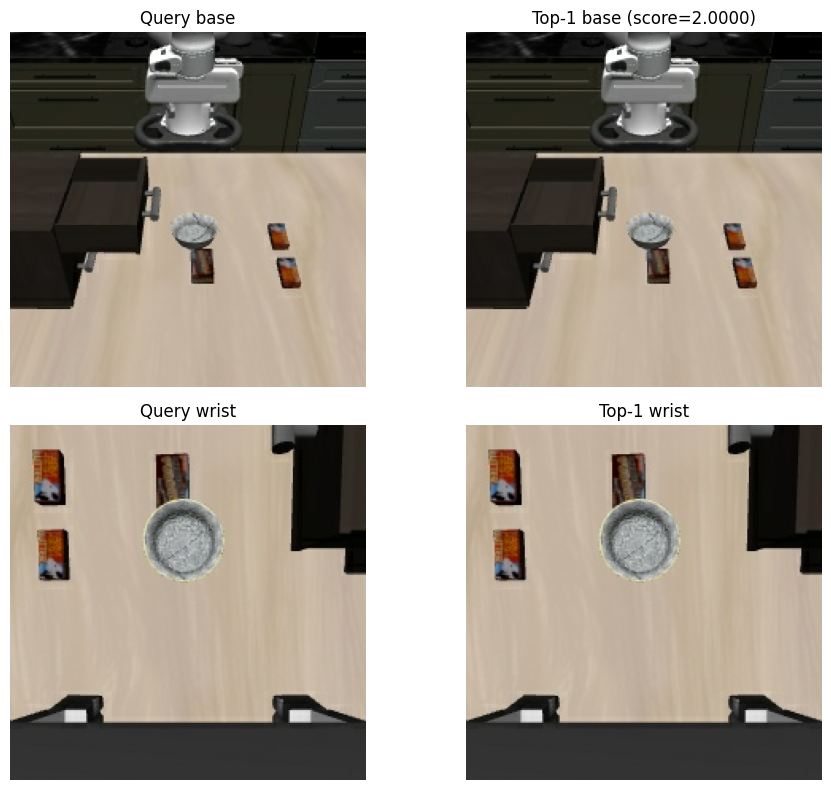

Top-1 metadata:
{'sample_idx': 14299, 'batch_idx': 111}


In [29]:
# Visual debug: query image vs top-1 fetched neighbor image.

def _img01(x):
    x = np.asarray(x)
    if x.ndim == 3 and x.shape[0] == 3:  # CHW -> HWC
        x = np.transpose(x, (1, 2, 0))
    if np.issubdtype(x.dtype, np.floating):
        lo, hi = float(x.min()), float(x.max())
        if lo >= -1.1 and hi <= 1.1:
            x = (x + 1.0) / 2.0
        x = np.clip(x, 0.0, 1.0)
    else:
        x = x.astype(np.float32) / 255.0
    return x

query_base = _img01(query_observation.images['base_0_rgb'][0])
query_wrist = _img01(query_observation.images['left_wrist_0_rgb'][0])
retr_base = _img01(nn_obs.images['base_0_rgb'][0])
retr_wrist = _img01(nn_obs.images['left_wrist_0_rgb'][0])

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(query_base);  axes[0, 0].set_title('Query base')
axes[0, 1].imshow(retr_base);   axes[0, 1].set_title(f'Top-1 base (score={distances[0]:.4f})')
axes[1, 0].imshow(query_wrist); axes[1, 0].set_title('Query wrist')
axes[1, 1].imshow(retr_wrist);  axes[1, 1].set_title('Top-1 wrist')
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

print('Top-1 metadata:')
print(metadata[0] if len(metadata) else '<empty>')